#  Аналіз ринку ноутбуків на базі 3 магазинів (Foxtrot. Telemart. Brain)

# Підготовка даних

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

## Завантажуємо дані

In [ ]:
foxtrot = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\foxtrot_data.csv")
brain = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\brain_data.csv")
telemart = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\telemart_data.csv")
cpu_rating = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\technical_city_cpu.csv")
gpu_rating = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\technical_city_gpu.csv")

In [ ]:
foxtrot = pd.DataFrame(foxtrot)
brain = pd.DataFrame(brain)
telemart = pd.DataFrame(telemart)
cpurating = pd.DataFrame(cpu_rating)
gpurating = pd.DataFrame(gpu_rating)

### Стандартизація датафрейму

#### Foxtrot

In [ ]:
foxtrot["shop"] ="foxtrot"
foxtrot["product_code"] = foxtrot["product_code"].astype(int)
foxtrot.info()

In [ ]:
def full_name(name: str, l: list):
    if not isinstance(name, str):
        return name
    
    name = name.strip()
    pattern = rf"\b{re.escape(name)}\b"

    # Шукаємо повнішу назву у рейтингу
    for full_name in l:
        if isinstance(full_name, str) and re.search(pattern.lower(), full_name.lower()):
            return full_name
    
    return name

In [ ]:
cpulist = cpu_rating['full_name'].tolist()
foxtrot['cpu'] = foxtrot['cpu'].apply(lambda x: full_name(x, cpulist))
foxtrot.info()

#### Brain

In [ ]:
brain.info()

#### Telemart

In [ ]:
telemart['shop'] = 'telemart'
telemart['product_code'] = telemart['product_code'].astype(int)
telemart.info()

#### CPU & GPU

In [ ]:
cpu_rating = cpu_rating.drop('name', axis=1)
gpu_rating = gpu_rating.drop('name', axis=1)

In [ ]:
cpu_rating = cpu_rating[cpu_rating['full_name'].notna()]
gpu_rating = gpu_rating[gpu_rating['full_name'].notna()]

In [ ]:
cpu_rating.info()

### Створення універсального датафрейму

#### Універсальний датафрейм

In [ ]:
all_shop = pd.concat([brain, telemart, foxtrot])
all_shop.info()

#### Чистка та стандартизація

In [ ]:
def clean_cpu(name: str):
    if not isinstance(name, str):
        return name
    if 'Intel Core Ultra' in name:
        return name.replace('-', " ")
    return name


all_shop['cpu'] = all_shop['cpu'].str.replace(r"\s\(.*?\)", "", regex=True).str.strip().apply(lambda x: clean_cpu(x))

In [ ]:
def clean_gpu(name):
    if not isinstance(name, str):
        return name
    if "AMD" in name:
        name = re.sub(r"\bGraphics\b", "", name).strip()
    return re.sub(r"\s+", " ", name)

gpulist = gpu_rating['full_name'].tolist()
all_shop['gpu'] = all_shop['gpu'].fillna("").apply(lambda x: full_name(x, gpulist)).apply(lambda x: clean_gpu(x))

#### Завантаження унікальних видів CPU & GPU у окемений файл 

In [ ]:
all_shop['cpu'].drop_duplicates().sort_values().to_csv("data/cpu_uniqe.csv", index=False, header=False)
all_shop['gpu'].drop_duplicates().sort_values().to_csv("data/gpu_uniqe.csv", index=False, header=False)
cpu_rating['full_name'].drop_duplicates().sort_values().to_csv("data/tcpu.csv", index=False, header=False)
gpu_rating['full_name'].drop_duplicates().sort_values().to_csv("data/tgpu.csv", index=False, header=False)

#### Створення універсального датафрейму та оптимізація назв колонок

In [104]:
laptop_rating = pd.merge(left=all_shop, right=cpu_rating, how="left", left_on="cpu", right_on="full_name", validate="m:1")
laptop_rating = pd.merge(left=laptop_rating, right=gpu_rating, how="left", left_on="gpu", right_on="full_name", suffixes=['_cpu', '_gpu'], validate="m:1")

In [106]:
laptop_rating = laptop_rating.rename(columns={
    'full_name':'gpu_name',
    'full_name_y':'cpu_name',
    'full_name_x': 'laptop_name'}
    )
laptop_rating = laptop_rating.drop_duplicates()
laptop_rating.info()

<class 'pandas.DataFrame'>
Index: 2030 entries, 0 to 2060
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   laptop_name      2030 non-null   str    
 1   price            2030 non-null   float64
 2   product_code     2030 non-null   object 
 3   shop             2030 non-null   str    
 4   product_url      2030 non-null   str    
 5   cpu              2030 non-null   str    
 6   gpu              2030 non-null   str    
 7   other            2030 non-null   str    
 8   rate_cpu         1899 non-null   float64
 9   cpu_name         1899 non-null   str    
 10  device_type_cpu  1899 non-null   str    
 11  performance_cpu  1899 non-null   float64
 12  year_cpu         1899 non-null   float64
 13  tdp_cpu          1899 non-null   float64
 14  cores            1899 non-null   float64
 15  threads          1899 non-null   float64
 16  rate_gpu         1791 non-null   float64
 17  gpu_name         1791 non-null

### Функція для отримання додактової характеристики

In [ ]:
import ast

def get_spec(string: str, key: str) -> str | None:
    try:
        d: dict = ast.literal_eval(string)
        return d.get(key)
    except:
        return None

# Аналіз даних

## Кількісь ноутбуків по магазинам

C:\Users\Niko.DESKTOP-QDQDF9G\AppData\Local\Temp\ipykernel_295392\1419079294.py:9: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  ax = sns.histplot(


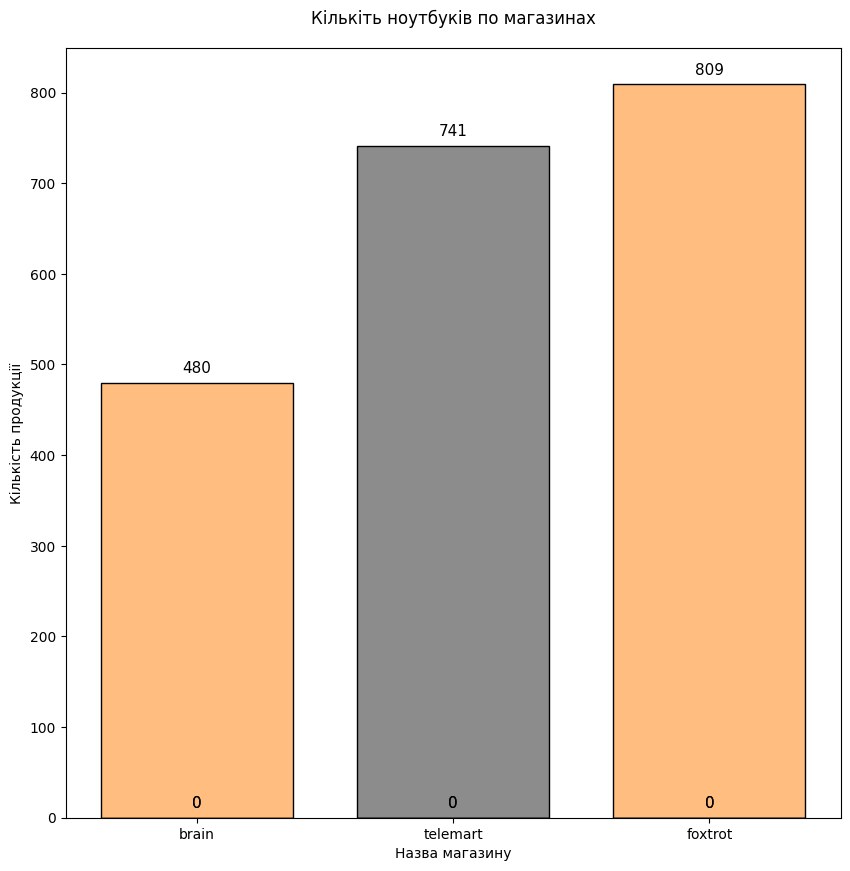

In [ ]:
from typing import cast
import matplotlib.container as mcontainer


palette = ["#FF7C01", "#181A18"]


plt.figure(figsize=[10, 10])
ax = sns.histplot(
    x='shop', 
    data=laptop_rating, 
    hue='shop',
    shrink=0.75,
    palette=palette,
    edgecolor='black',
    legend=False, 
    cbar=True
)


for container in ax.containers:
    ax.bar_label(
        cast(mcontainer.BarContainer, container),
        fontsize=11, 
        padding=5,
        label_type='edge', 
        fmt='%d'
    )
plt.title("Кількіть ноутбуків по магазинах", y=1.02)
plt.xlabel("Назва магазину")
plt.ylabel("Кількість продукції")
plt.show()

## Середній рейтинговий показник для ноутбука 

#### Формула  (cou_rating + gpu_rating) // 2

In [121]:
laptop_rating["avg_perf_score"] = (laptop_rating['rate_cpu'] + laptop_rating['rate_gpu']) // 2

In [122]:
laptop_rating.sort_values(by=['avg_perf_score', 'price'])
laptop_rating[['cpu', 'cpu_name', "rate_cpu", 'gpu', 'gpu_name', 'rate_gpu']].head(10)
# 'gpu', 'gpu_name', 'rate_gpu'

,cpu,cpu_name,rate_cpu,gpu,gpu_name,rate_gpu
0,AMD Ryzen 5 7520U,AMD Ryzen 5 7520U,1419.0,AMD Radeon 610M,AMD Radeon 610M,827.0
1,Intel Core 3 N355,Intel Core 3 N355,1315.0,Intel Graphics 4 Xe3 Panther Lake iGPU,Intel Graphics 4 Xe3 Panther Lake iGPU,454.0
2,AMD Ryzen 5 7430U,AMD Ryzen 5 7430U,1014.0,AMD Radeon (Ryzen 7000),NaN,NaN
3,Intel Core i5-1334U,Intel Core i5-1334U,1161.0,Intel Iris Xe Graphics G7,Intel Iris Xe Graphics G7,498.0
4,Intel Core 5 210H,Intel Core 5 210H,879.0,NVIDIA GeForce RTX 3050 8 GB,NVIDIA GeForce RTX 3050 8 GB,209.0
5,Intel Core i5-1334U,Intel Core i5-1334U,1161.0,Intel Iris Xe Graphics G7,Intel Iris Xe Graphics G7,498.0
6,Intel Core i5-1334U,Intel Core i5-1334U,1161.0,Intel UHD Graphics 730 (Rocket Lake),Intel UHD Graphics 730 (Rocket Lake),436.0
7,AMD Ryzen 5 7235HS,AMD Ryzen 5 7235HS,1211.0,NVIDIA GeForce RTX 3050 8 GB,NVIDIA GeForce RTX 3050 8 GB,209.0
8,Intel Core i7-13650HX,Intel Core i7-13650HX,443.0,NVIDIA GeForce RTX 5060 Ti 16 GB,NVIDIA GeForce RTX 5060 Ti 16 GB,56.0
9,Intel Core i5-1235U,Intel Core i5-1235U,1200.0,Intel Iris Xe Graphics eligible,NaN,NaN


In [123]:
# cpu_na = laptop_rating[laptop_rating['rate_gpu'].isna()]
# cpu_na[['gpu']].drop_duplicates()

In [124]:
laptop_rating.to_csv("laptop_rating.csv", index=False)